# 02 Baseline Results and Analysis

**Phases 2 and 3 of the project.** The baseline is the DQN of TD3 (target network + experience replay) with TD3's hyperparameters, trained on dev-train with 3 seeds (`configs/baseline.json`, trained with `scripts/run_experiment.sh configs/baseline.json`). This notebook loads the saved runs and answers two questions:

1. **How good is the baseline?** Training curves, validation results, and the one-time baseline evaluation on the eval month.
2. **Why does it fail?** Overestimation, memorisation, decisions by noise, trading behaviour. Each finding motivates a Phase 4 experiment.

In [1]:
import sys
import json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import Image, display

from rl_trading.train import prepare_splits
from rl_trading.envs import make_env
from rl_trading.agents import load_agent
from rl_trading.evaluate import (plot_training_runs, summarize_experiment, diagnose_agent,
                                 rollout_with_q, policy_agreement)

FIG_DIR = ROOT / "figures"
RUNS = ROOT / "runs" / "baseline"
SEEDS = [0, 1, 2]
with open(ROOT / "configs" / "baseline.json") as f:
    config = json.load(f)
POSITIONS, GAMMA = config["positions"], config["agent_params"]["gamma"]
pd.set_option("display.width", 160)

SURF, INK, INK2, GRID, NEUTRAL = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df", "#8a8984"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

def style_axis(ax, title):
    ax.set_facecolor(SURF)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, labelsize=9, length=0)
    ax.set_title(title, loc="left", color=INK, fontsize=10.5)

## 1. Baseline configuration

| Setting | Value | Source |
|---|---|---|
| Algorithm | DQN, target network (hard sync every 250 updates), experience replay (50k) | TD3 |
| Network | 7 inputs, 2 hidden layers of 128 (ReLU), 5 outputs | TD2/TD3 |
| lr, γ, batch | 1e-4, 0.99, 64 | TD3 |
| Features, positions, reward | 5 default features, [-1, 0, 0.5, 1, 2], log return | instruction notebook |
| Episodes | 100 passes over dev-train (7,295 steps each), one update per step | |
| ε schedule | 1.0 x 0.912 per episode, minimum 0.01 from episode 51 | TD3's shape (0.99 per episode is tuned for 1,000 short CartPole episodes) |
| Reported model | the last one (not the best validation checkpoint, see below) | |

## 2. Training behaviour

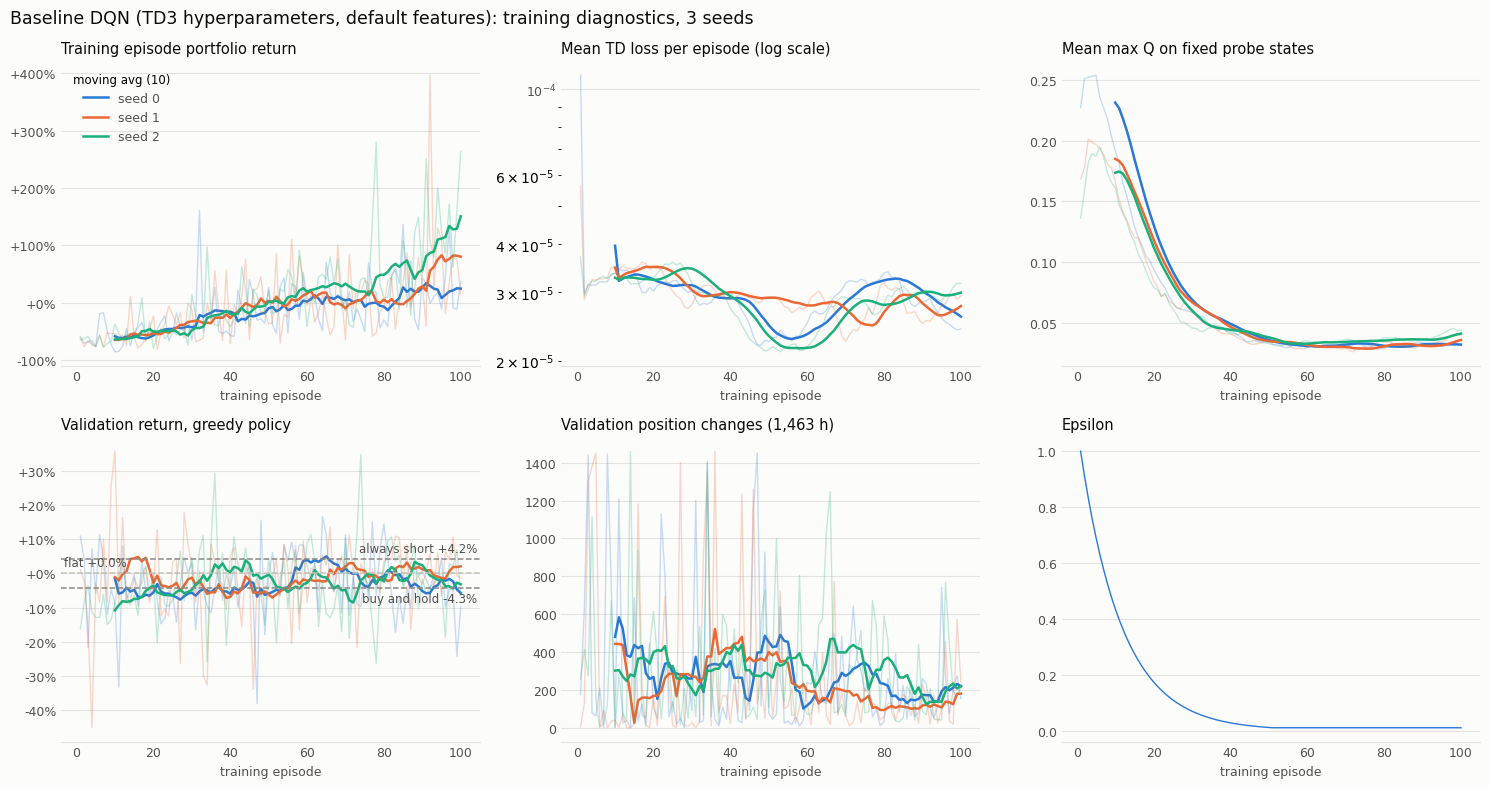

In [2]:
fig = plot_training_runs([RUNS / f"seed_{s}" for s in SEEDS],
                         benchmarks={"buy and hold": -0.0427, "always short": 0.0424, "flat": 0.0},
                         title="Baseline DQN (TD3 hyperparameters, default features): training diagnostics, 3 seeds",
                         save_path=FIG_DIR / "phase2_baseline_training.png")
plt.show()

- The training return rises from random-agent level (about -60%) to +25% / +80% / +151% per pass as ε falls: the agent learns the training data.
- The validation return of the greedy policy stays around buy and hold and jumps by 8 to 11 points from one episode to the next, even at ε = 0.01.
- The loss is tiny (about 3e-5) because hourly rewards are about 0.001.

## 3. Validation results (last model, 10 episodes per env)

In [3]:
summary, per_seed = summarize_experiment(RUNS)
table = per_seed.pivot(index="env", columns="seed", values="portfolio_return")
table["mean"], table["std"] = table.mean(axis=1), table.std(axis=1)
table["buy and hold"] = [-0.0427, -0.0270, -0.0155]
table["always short"] = [0.0424, 0.0267, 0.0153]
table.map(lambda x: f"{x:+.2%}")

seed,seed_0,seed_1,seed_2,mean,std,buy and hold,always short
env,,,,,,,
val,-9.90%,-1.27%,-6.33%,-5.83%,+4.33%,-4.27%,+4.24%
val_w1,-11.28%,+1.55%,-10.13%,-6.62%,+7.10%,-2.70%,+2.67%
val_w2,-1.17%,-3.83%,+4.30%,-0.23%,+4.14%,-1.55%,+1.53%


**Baseline on validation: -5.83% ± 4.33%.** Below flat, slightly below buy and hold (within the seed spread), far above the random agent (-18%): no measurable skill yet.

The best in-training checkpoints would show +17% to +36%, but they were selected on the same noisy validation evaluations they would be reported on (the maximum of 100 noisy numbers), so they are not used.

### One-time baseline evaluation on the eval month

Run once on 2026-09-28 with the unchanged `evaluate_agent`; seed 0 was fixed in advance as the official baseline CSV. Only the portfolio return is shown here: the market return of the eval month is not inspected before the final model is frozen.

In [4]:
eval_files = {0: "baseline_evaluation_results.csv", 1: "baseline_seed1_evaluation_results.csv", 2: "baseline_seed2_evaluation_results.csv"}
eval_rows = []
for seed, name in eval_files.items():
    df = pd.read_csv(ROOT / "eval" / name)
    eval_rows.append({"seed": seed, "file": name, "episodes": len(df), "steps": int(df["steps"].iloc[0]),
                      "mean portfolio_return": f"{df['portfolio_return'].mean():+.2%}"})
pd.DataFrame(eval_rows).set_index("seed")

,file,episodes,steps,mean portfolio_return
seed,,,,
0,baseline_evaluation_results.csv,10,743,+22.61%
1,baseline_seed1_evaluation_results.csv,10,743,+23.52%
2,baseline_seed2_evaluation_results.csv,10,743,+13.20%


The eval numbers (+13% to +24%) are much higher than on validation (-10% to -1%) for the same models. The models hold mostly long exposure, so this reflects the direction of the eval month, not skill. Consequence: every later decision about the action set, leverage or long/short tendency is justified with validation evidence only, and the main comparison between baseline and final agent is made on validation.

## 4. Why does the baseline fail?

For each seed I run one greedy episode on the training hours and on the validation hours and log the Q-values of all actions at every step.

In [5]:
splits, _ = prepare_splits(config)
envs = {"dev_train": make_env(splits["dev_train"], positions=POSITIONS),
        "val": make_env(splits["val"], positions=POSITIONS)}
agents = {s: load_agent(RUNS / f"seed_{s}" / "last.pt") for s in SEEDS}

diag = pd.concat([diagnose_agent(agents[s], envs, gamma=GAMMA).assign(seed=s) for s in SEEDS]).reset_index()
cols = ["seed", "env", "return", "mean_pred_Q", "mean_realised_G", "overestimation",
        "corr_pos_next_1h", "action_gap", "changes", "mean_hold_h", "fees_approx"]
diag[cols].round(4)

Downloaded data: 9,672 candles, 2025-08-10 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours
dev_train: 7,296 candles, 2025-08-17 00:00:00+00:00 to 2026-06-16 23:00:00+00:00; no missing hours
val: 1,464 candles, 2026-06-17 00:00:00+00:00 to 2026-08-16 23:00:00+00:00; no missing hours
eval: 744 candles, 2026-08-17 00:00:00+00:00 to 2026-09-16 23:00:00+00:00; no missing hours


,seed,env,return,mean_pred_Q,mean_realised_G,overestimation,corr_pos_next_1h,action_gap,changes,mean_hold_h,fees_approx
0,0,dev_train,0.2128,0.0324,0.0004,0.0320,0.0216,0.0003,1019,7.1520,0.1320
1,0,val,-0.0978,0.0324,-0.0076,0.0400,-0.0116,0.0004,153,9.5000,0.0193
2,1,dev_train,0.3632,0.0399,0.0050,0.0349,0.0561,0.0000,1115,6.5367,0.1236
3,1,val,-0.0128,0.0398,0.0014,0.0384,0.0158,0.0000,240,6.0705,0.0224
4,2,dev_train,0.3782,0.0442,0.0045,0.0397,0.0731,0.0002,1046,6.9675,0.1435
5,2,val,-0.0633,0.0441,-0.0056,0.0497,0.0027,0.0002,211,6.9009,0.0280


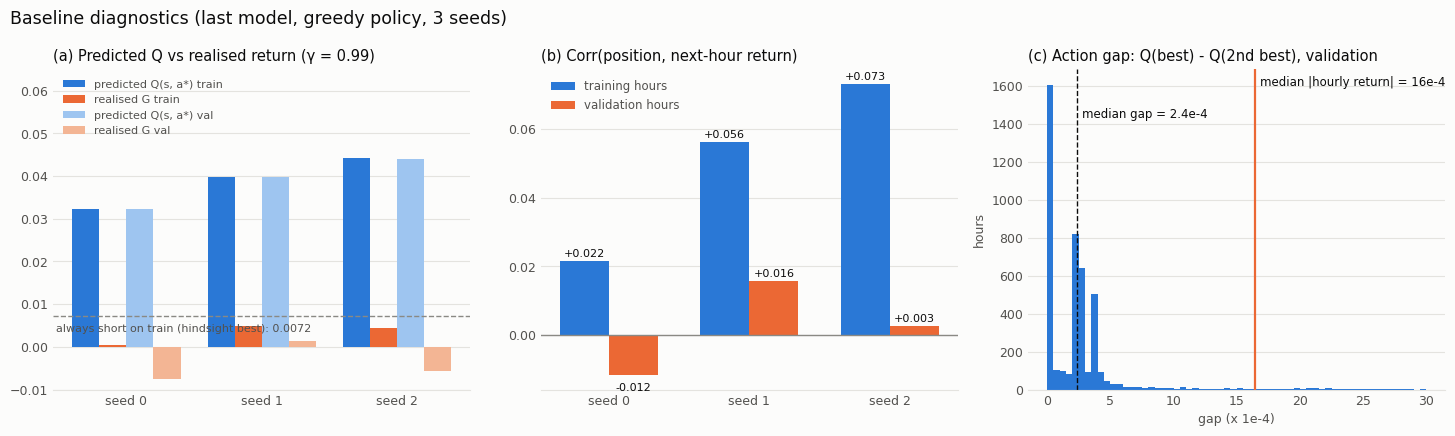

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), facecolor=SURF)
x = np.arange(len(SEEDS))

# (a) overestimation
ax = axes[0]
style_axis(ax, "(a) Predicted Q vs realised return (γ = 0.99)")
w = 0.2
for i, (env_name, label) in enumerate([("dev_train", "train"), ("val", "val")]):
    d = diag[diag["env"] == env_name].sort_values("seed")
    ax.bar(x + (2 * i - 1.5) * w, d["mean_pred_Q"], w, color=BLUE if i == 0 else "#9ec5f0", label=f"predicted Q(s, a*) {label}")
    ax.bar(x + (2 * i - 0.5) * w, d["mean_realised_G"], w, color=ORANGE if i == 0 else "#f3b594", label=f"realised G {label}")
ax.axhline(0.0072, color=NEUTRAL, ls="--", lw=1)
ax.annotate("always short on train (hindsight best): 0.0072", (0.0, 0.0072), xycoords=("axes fraction", "data"),
            xytext=(2, -11), textcoords="offset points", fontsize=8, color=INK2)
ax.set_xticks(x, [f"seed {s}" for s in SEEDS])
ax.set_ylim(-0.01, 0.065)
ax.legend(frameon=False, fontsize=8, labelcolor=INK2, loc="upper left")

# (b) memorisation
ax = axes[1]
style_axis(ax, "(b) Corr(position, next-hour return)")
for i, (env_name, color, label) in enumerate([("dev_train", BLUE, "training hours"), ("val", ORANGE, "validation hours")]):
    d = diag[diag["env"] == env_name].sort_values("seed")
    xs = x + (i - 0.5) * 0.35
    ax.bar(xs, d["corr_pos_next_1h"], 0.35, color=color, label=label)
    for xi, v in zip(xs, d["corr_pos_next_1h"]):
        ax.annotate(f"{v:+.3f}", (xi, v), xytext=(0, 3 if v >= 0 else -11), textcoords="offset points",
                    ha="center", fontsize=8, color=INK)
ax.axhline(0, color=NEUTRAL, lw=1)
ax.set_xticks(x, [f"seed {s}" for s in SEEDS])
ax.legend(frameon=False, fontsize=8.5, labelcolor=INK2)

# (c) action gap on validation
ax = axes[2]
style_axis(ax, "(c) Action gap: Q(best) - Q(2nd best), validation")
val_rollouts = {}
for s in SEEDS:
    np.random.seed(0)
    val_rollouts[s] = rollout_with_q(agents[s], envs["val"])
q_all = np.concatenate([r[[f"q_{i}" for i in range(len(POSITIONS))]].to_numpy() for r in val_rollouts.values()])
q_sorted = np.sort(q_all, axis=1)
gaps = q_sorted[:, -1] - q_sorted[:, -2]
typical_move = np.median(np.abs(val_rollouts[0]["market_log_return"]))
ax.hist(gaps * 1e4, bins=60, range=(0, 30), color=BLUE)
ax.axvline(typical_move * 1e4, color=ORANGE, lw=1.6)
ax.annotate(f"median |hourly return| = {typical_move * 1e4:.0f}e-4", (typical_move * 1e4, 0.95),
            xycoords=("data", "axes fraction"), xytext=(4, 0), textcoords="offset points", fontsize=8.5, color=INK)
ax.axvline(np.median(gaps) * 1e4, color=INK, lw=1, ls="--")
ax.annotate(f"median gap = {np.median(gaps) * 1e4:.1f}e-4", (np.median(gaps) * 1e4, 0.85),
            xycoords=("data", "axes fraction"), xytext=(4, 0), textcoords="offset points", fontsize=8.5, color=INK)
ax.set_xlabel("gap (x 1e-4)", color=INK2, fontsize=9)
ax.set_ylabel("hours", color=INK2, fontsize=9)

fig.suptitle("Baseline diagnostics (last model, greedy policy, 3 seeds)", x=0.01, ha="left", color=INK, fontsize=12.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "phase3_diagnostics.png", dpi=150, facecolor=SURF)
plt.show()

**(a) Overestimation.** The network predicts about 0.039 for its chosen action; what it realises afterwards is about +0.003 on training hours and -0.004 on validation: more than ten times too optimistic, and five times above the best strategy in hindsight. This is the bias of Session 2 (slide 14): the target takes the max over Q-values that differ only by noise, and with γ = 0.99 that bias is bootstrapped over about 100 steps.

**(b) Memorisation.** On the training hours the position held correlates with the next hour's return (up to +0.07); on validation this vanishes. The agent has learned the timing of hours it has seen 100 times, not a pattern that transfers.

**(c) Decisions by noise.** The best and the second-best action differ by a median of 2.4e-4 in Q, seven times less than a typical hourly move. Which position wins is decided by noise, as the agreement between checkpoints shows:

In [7]:
feature_cols = [c for c in splits["val"].columns if "feature" in c]
val_states = np.column_stack([splits["val"][feature_cols].to_numpy(np.float32),
                              np.zeros((len(splits["val"]), 2), np.float32)])   # every validation hour, agent flat
rows = [{"pair": f"seed {s}: best vs last checkpoint",
         "same action": policy_agreement(load_agent(RUNS / f"seed_{s}" / "best.pt"), agents[s], val_states)} for s in SEEDS]
rows += [{"pair": f"seed {a} vs seed {b} (last)", "same action": policy_agreement(agents[a], agents[b], val_states)}
         for a, b in [(0, 1), (0, 2), (1, 2)]]
pd.DataFrame(rows).set_index("pair").map(lambda v: f"{v:.0%}")

,same action
pair,
seed 0: best vs last checkpoint,3%
seed 1: best vs last checkpoint,1%
seed 2: best vs last checkpoint,1%
seed 0 vs seed 1 (last),18%
seed 0 vs seed 2 (last),2%
seed 1 vs seed 2 (last),2%


The best and the last checkpoint of the same run choose the same action on only 1 to 3% of validation hours. This is the value-based version of the "performance collapse" in Session 5: a small parameter change flips the argmax in many states, so the greedy policy jumps.

### Trading behaviour on validation

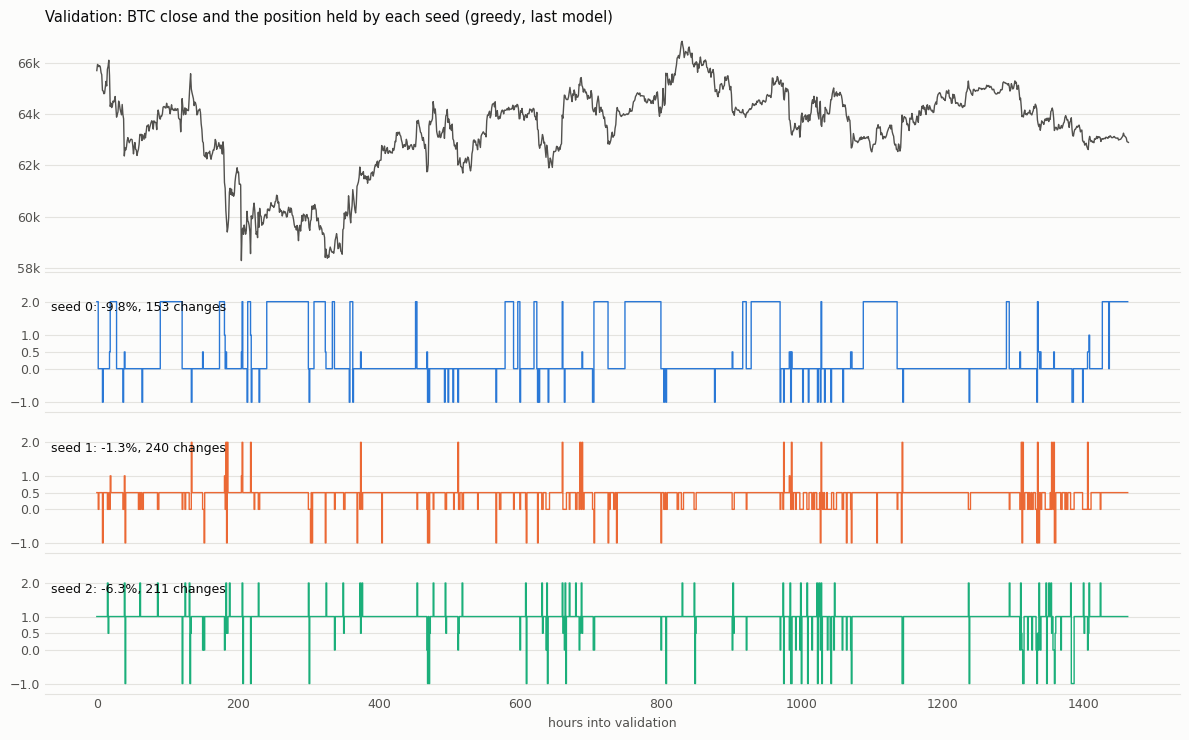

In [8]:
close = splits["val"]["close"].to_numpy()
fig, axes = plt.subplots(4, 1, figsize=(12, 7.5), facecolor=SURF, sharex=True, gridspec_kw=dict(height_ratios=[2, 1, 1, 1]))
style_axis(axes[0], "Validation: BTC close and the position held by each seed (greedy, last model)")
axes[0].plot(close, color=INK2, lw=1)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
for s, color in zip(SEEDS, [BLUE, ORANGE, AQUA]):
    ax = axes[s + 1]
    style_axis(ax, "")
    r = val_rollouts[s]
    ax.step(np.arange(len(r)), r["position"], where="post", color=color, lw=1)
    ax.set_yticks(POSITIONS)
    ax.set_ylim(-1.3, 2.3)
    d = diag[(diag["seed"] == s) & (diag["env"] == "val")].iloc[0]
    ax.text(0.005, 0.92, f"seed {s}: {d['return']:+.1%}, {int(d['changes'])} changes", transform=ax.transAxes,
            fontsize=9, color=INK, va="top")
axes[-1].set_xlabel("hours into validation", color=INK2, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "phase3_val_positions.png", dpi=150, facecolor=SURF)
plt.show()

In [9]:
diag.pivot(index="seed", columns="env", values=[f"share_pos_{p:g}" for p in POSITIONS]).round(2)

share_pos_-1       share_pos_0       share_pos_0.5       share_pos_1      share_pos_2      
env     dev_train   val   dev_train   val     dev_train   val   dev_train  val   dev_train   val
seed                                                                                            
0            0.04  0.03        0.63  0.70          0.02  0.02        0.00  0.0        0.31  0.25
1            0.03  0.02        0.09  0.12          0.86  0.84        0.01  0.0        0.02  0.01
2            0.03  0.02        0.03  0.03          0.01  0.02        0.90  0.9        0.03  0.03

Every seed has a favourite position (seed 0 flat, seed 1 at 0.5, seed 2 long) with identical shares on training and validation, plus 1 to 2 hour excursions that cost fees. There is no "lazy short" despite the bear-market training year: the Q-values of all actions are almost equal, so which position wins is not a market judgement.

## 5. Hypotheses for Phase 4 (order of testing)

Format: I observe X, I believe the cause is Y, I test Z, I expect W. Each test changes one thing against the current best config, with 3 seeds. The order was revised with evidence: EXP-01 showed that overfitting, not signal scale, was the main bottleneck, so the data experiments moved forward; the feature analysis then moved the horizon γ ahead of new features.

| # | Observation | Suspected cause | Planned test | Tested in (see EXPERIMENTS.md) | Expectation |
|---|---|---|---|---|---|
| 1 | Q almost constant across states, action gap 2.4e-4 | signal scale: inputs nearly constant (about 1.000 ± 0.004), rewards about 0.001 | input normalisation, reward scaling | EXP-01 (normalisation); reward scaling not run after EXP-01 | larger action gaps, more stable policy |
| 2 | train +32% vs validation -6%, correlation +0.07 → 0 | too little data seen too often (100 passes over one regime) | random-start episodes, more training history | EXP-02, EXP-03, EXP-04 | smaller gap, positive correlation on validation |
| 3 | Q ten times too high | max bias of DQN, bootstrapped with γ = 0.99 | Double DQN | EXP-07 | predicted Q closer to realised G |
| 4 | bias accumulates over about 100 steps | horizon too long | lower γ or n-step returns | EXP-05 (γ 0.9), EXP-06 (γ 0.5); n-step not run | less overestimation, more stable targets |
| 5 | agent sees only the last hour | features too weak | multi-horizon returns, volatility, time of day | feature analysis (notebook 03), EXP-09 | positive correlation on validation |
| 6 | 1 to 2 hour blips cost 2 to 3% fees | churn, no switching cost in the target | turnover penalty, ensembles and others | EXP-12 (turnover penalty), EXP-13 and EXP-14 (ensembles) | fewer trades, more stable decisions |